In [1]:
import seabreeze.spectrometers as sb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [2]:
spec = sb.Spectrometer.from_first_available()

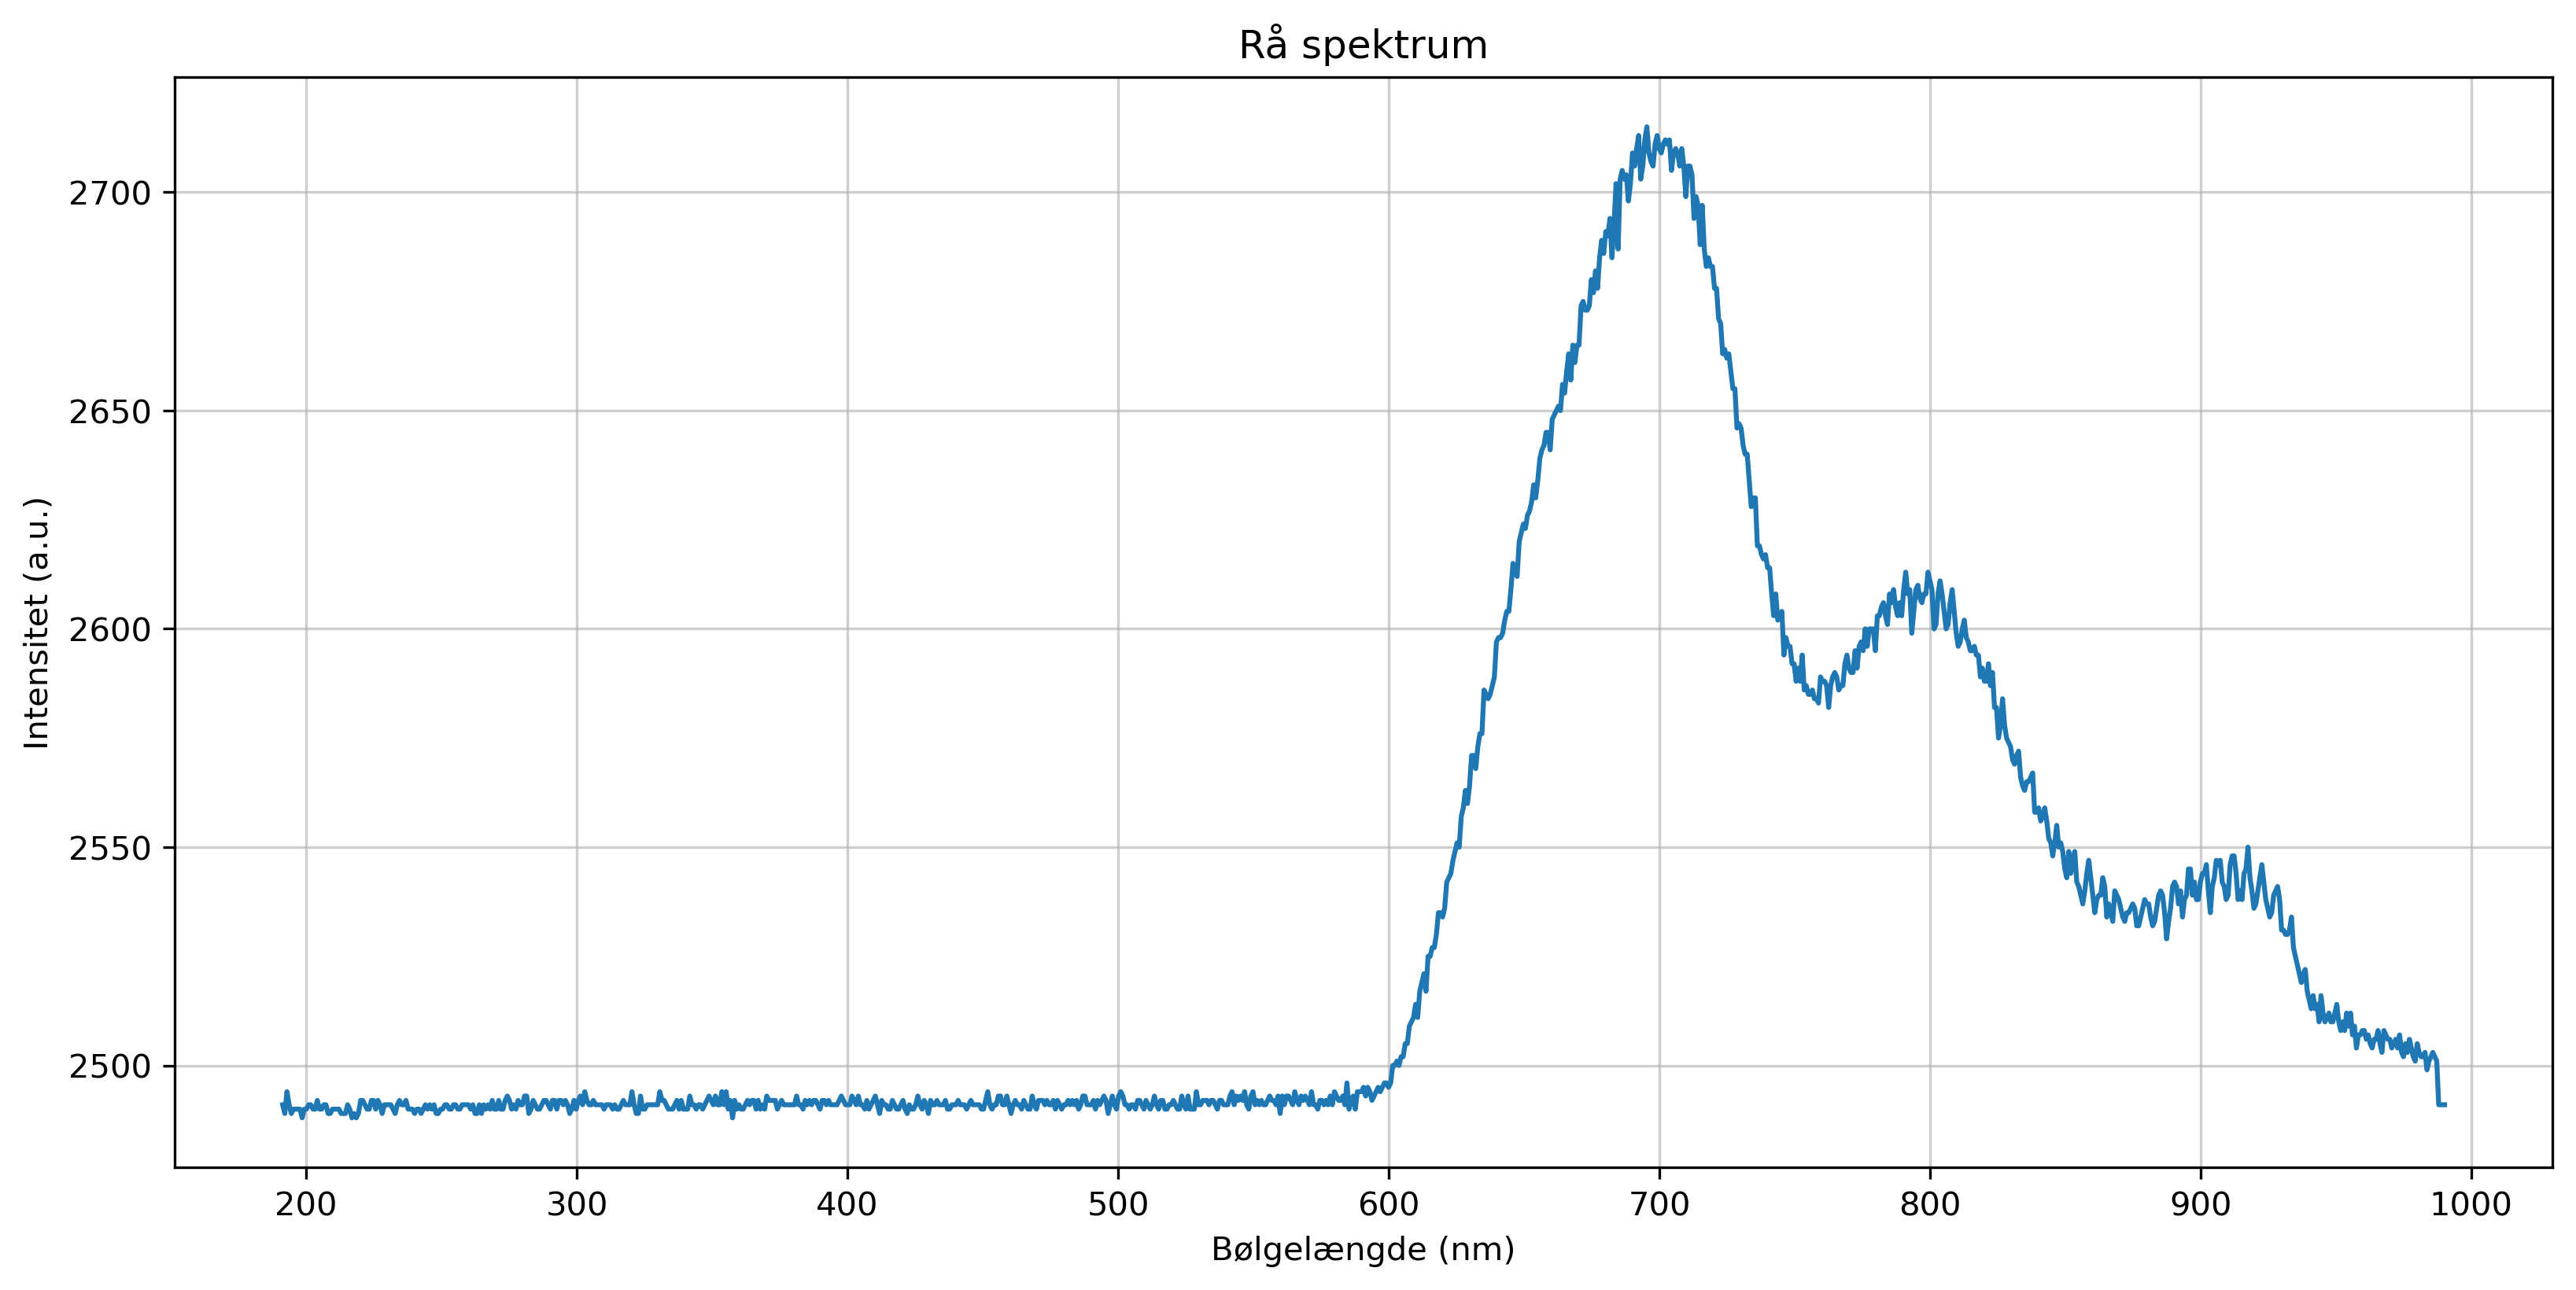

In [31]:
integration_time = 100_000 # mikrosekunder
navn = "finger"

spec.integration_time_micros(integration_time)

bølgelængder = np.array(spec.wavelengths())
intensiteter = np.array(spec.intensities())

np.savez(
    f"målinger/{navn}.npz",
    wavelengths=bølgelængder,
    intensities=intensiteter,
    integration_time_us=integration_time
)

plt.figure(figsize=(13, 6), dpi= 300)
plt.plot(bølgelængder, intensiteter)
plt.xlabel("Bølgelængde (nm)")
plt.ylabel("Intensitet (a.u.)")
plt.title("Rå spektrum")
plt.grid(True, alpha=0.6)

plt.show()

In [33]:
import numpy as np

def gem_spektrum(spec, integration_time_us, filnavn):
    spec.integration_time_micros(integration_time_us)
    bølgelængder = np.array(spec.wavelengths())
    intensiteter = np.array(spec.intensities())
    
    np.savez(
        filnavn,
        bølgelængder=bølgelængder,
        intensiteter=intensiteter,
        integration_time_us=integration_time_us
    )
    print(f"Gemt som {filnavn}")

In [38]:
gem_spektrum(spec, 20_000, "målinger/reference.npz")

Gemt som målinger/reference.npz


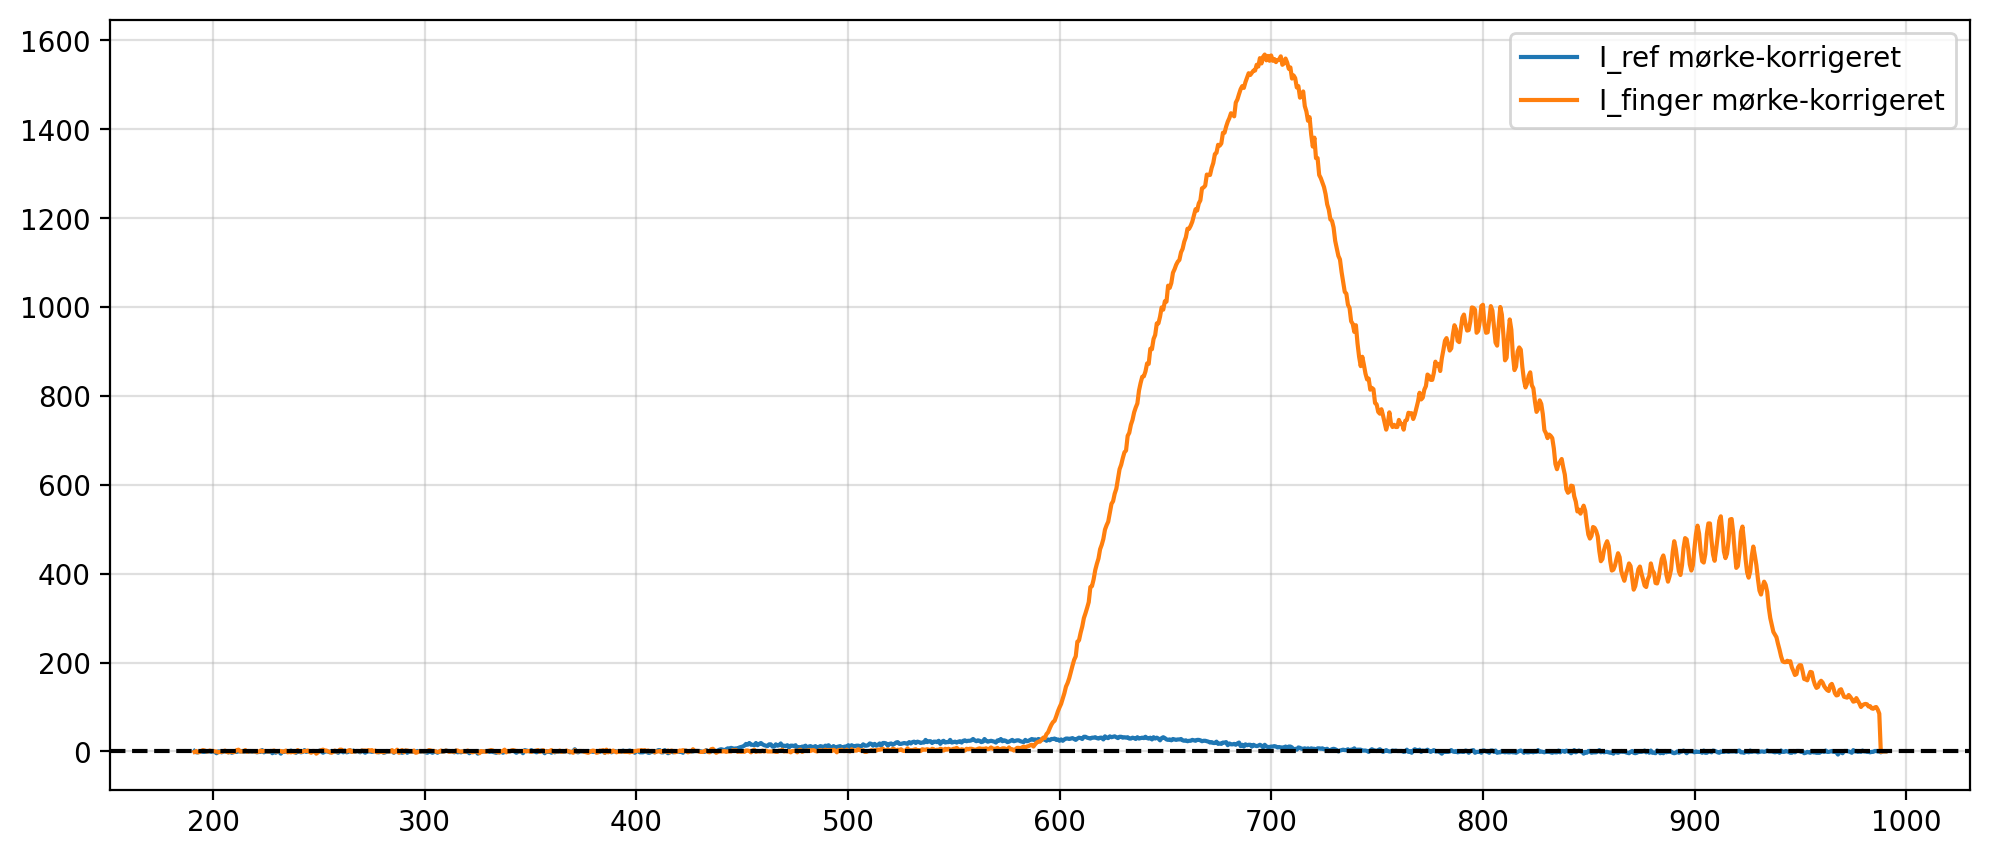

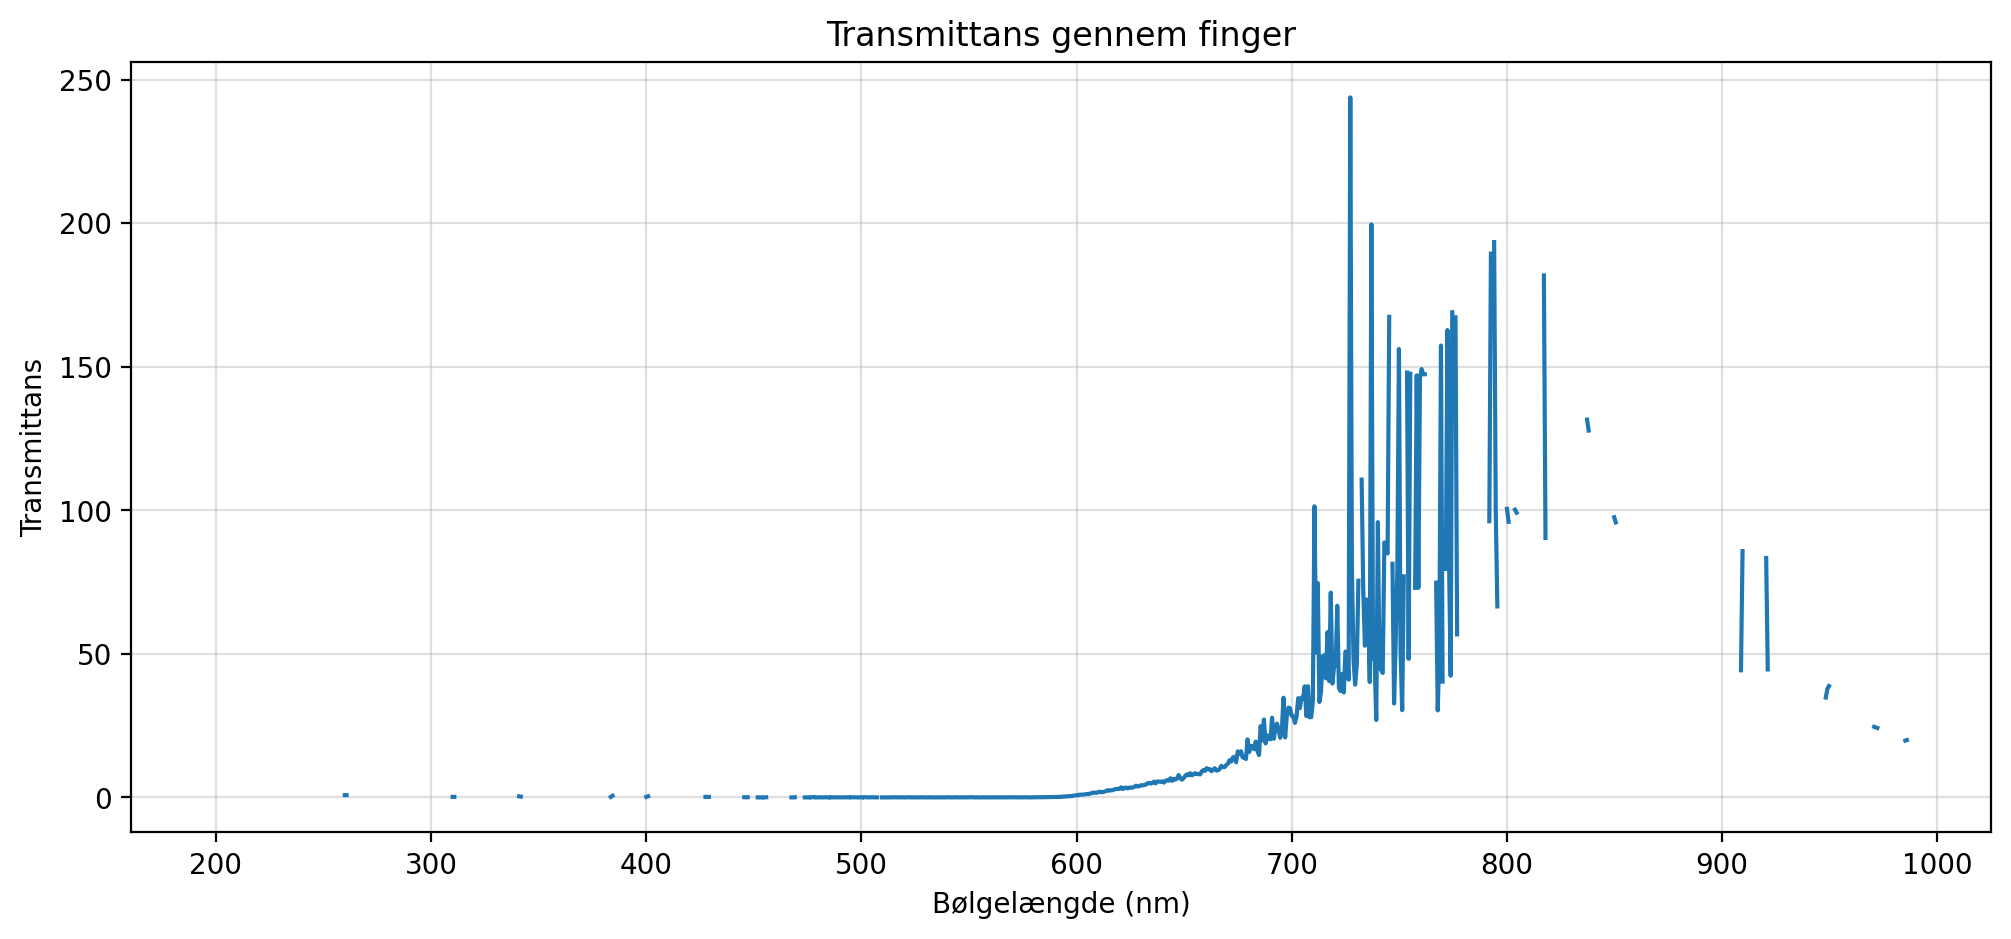

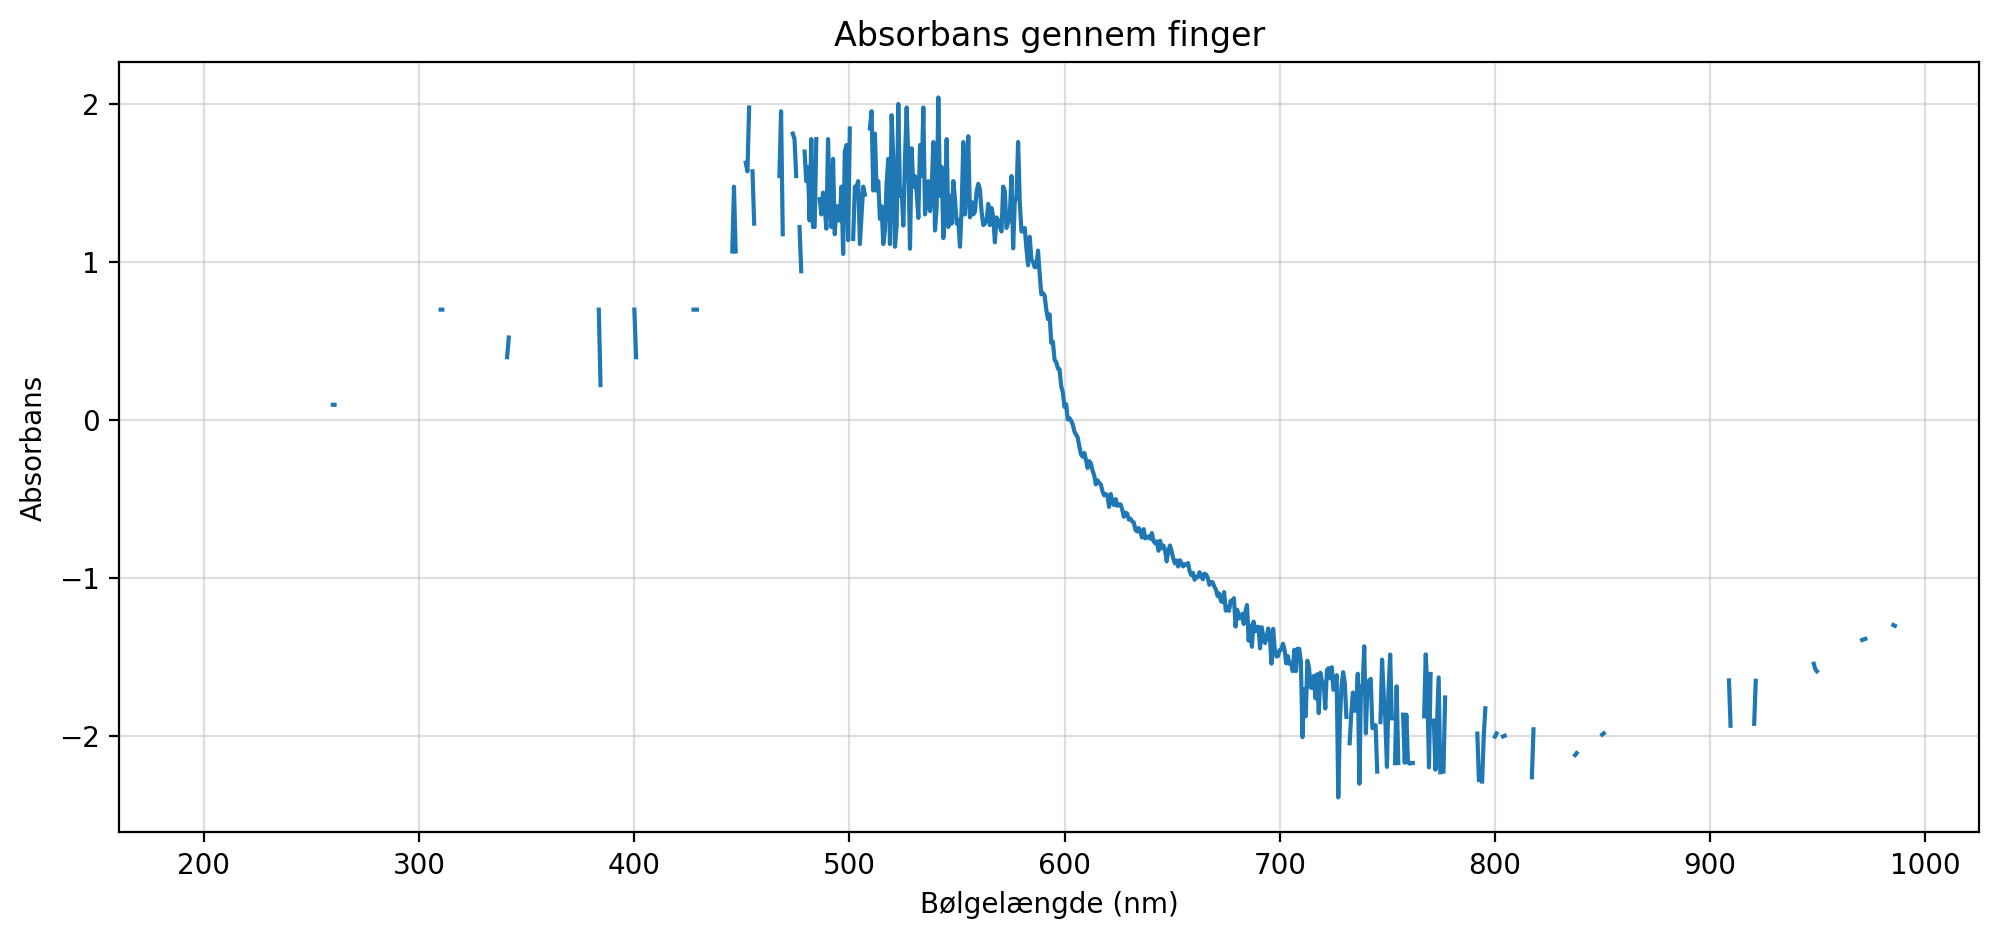

In [43]:
import numpy as np
import matplotlib.pyplot as plt

mørke_kort = np.load("målinger/mørke_kort.npz")
reference = np.load("målinger/reference.npz")
mørke_lang = np.load("målinger/mørke_lang.npz")
finger = np.load("målinger/finger.npz")

bølgelængder = reference["bølgelængder"]

I_ref = reference["intensiteter"] - mørke_kort["intensiteter"]
I_finger = finger["intensiteter"] - mørke_lang["intensiteter"]

t_ref = reference["integration_time_us"]
t_finger = finger["integration_time_us"]

I_ref_rate = I_ref / t_ref
I_finger_rate = I_finger / t_finger

gyldig = I_ref > 0
T = np.full_like(I_ref, np.nan, dtype=float)
A = np.full_like(I_ref, np.nan, dtype=float)
import numpy as np
import matplotlib.pyplot as plt

mørke_kort = np.load("målinger/mørke_kort.npz")
reference = np.load("målinger/reference.npz")
mørke_lang = np.load("målinger/mørke_lang.npz")
finger = np.load("målinger/finger.npz")

bølgelængder = reference["bølgelængder"]

I_ref = reference["intensiteter"] - mørke_kort["intensiteter"]
I_finger = finger["intensiteter"] - mørke_lang["intensiteter"]

t_ref = reference["integration_time_us"]
t_finger = finger["integration_time_us"]

I_ref_rate = I_ref / t_ref
I_finger_rate = I_finger / t_finger

gyldig = (I_ref_rate > 0) & (I_finger_rate > 0)

plt.figure(figsize=(12,5), dpi=200)
plt.plot(bølgelængder, I_ref, label="I_ref mørke-korrigeret")
plt.plot(bølgelængder, I_finger, label="I_finger mørke-korrigeret")
plt.axhline(0, color="k", linestyle="--")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

T = np.full_like(I_ref_rate, np.nan, dtype=float)
A = np.full_like(I_ref_rate, np.nan, dtype=float)

T[gyldig] = I_finger_rate[gyldig] / I_ref_rate[gyldig]
A[gyldig] = -np.log10(T[gyldig])

plt.figure(figsize=(12, 5), dpi=200)
plt.plot(bølgelængder, T)
plt.xlabel("Bølgelængde (nm)")
plt.ylabel("Transmittans")
plt.title("Transmittans gennem finger")
plt.grid(True, alpha=0.4)
plt.show()

plt.figure(figsize=(12, 5), dpi=200)
plt.plot(bølgelængder, A)
plt.xlabel("Bølgelængde (nm)")
plt.ylabel("Absorbans")
plt.title("Absorbans gennem finger")
plt.grid(True, alpha=0.4)
plt.show()